# Problem Set 1
Answer for Group A2

# Problem 1: Tensors and Automatic Differentiation

PyTorch tensors are similar to NumPy arrays but can run on GPUs and
support automatic differentiation. In this problem, you will explore
tensor operations and PyTorch’s autograd system.

In [66]:
# install packages
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [67]:
# torch set up
torch.manual_seed(42)
rng_state = torch.get_rng_state()

if torch.backends.mps.is_available():
    device = torch.device("mps") # Apple Silicon Metal Performance Shaders
elif torch.cuda.is_available():
    device = torch.device("cuda") # GPU
else:
    device = torch.device("cpu")

**(1a)** Create the following tensors and perform the specified
operations:

1.  Create a tensor `a` containing the values \[1.0, 2.0, 3.0, 4.0,
    5.0\]

In [68]:
# 1.a.1
VALUES = [1.0, 2.0, 3.0, 4.0, 5.0]
a = torch.tensor(VALUES, dtype=torch.float32).to(device)
print(f'a: {a}')

a: tensor([1., 2., 3., 4., 5.])


2.  Create a 3×3 tensor `B` filled with ones

In [69]:
# 1.a.2
SHAPE = (3,3)
B = torch.ones(SHAPE, dtype=torch.float32).to(device)
print(f'B: \n {B}')

B: 
 tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])


3.  Reshape `a` to a 5×1 column vector

In [70]:
# 1.a.3
a_transposed = a.reshape(-1,1)  # didn't use .T as a is a 1D vector
print(f'a transposed to a 5x1 column vector: \n {a_transposed}')

a transposed to a 5x1 column vector: 
 tensor([[1.],
        [2.],
        [3.],
        [4.],
        [5.]])


4.  Compute the element-wise square of `a`

In [71]:
# 1.a.4
a_squared = a * a
print(f'a squared element-wise: \n {a_squared}')

a squared element-wise: 
 tensor([ 1.,  4.,  9., 16., 25.])


5.  Compute the matrix product of `B` with itself

In [72]:
# 1.a.5
B_squared = B @ B
print(f'B squared (matrix product): \n {B_squared}')

B squared (matrix product): 
 tensor([[3., 3., 3.],
        [3., 3., 3.],
        [3., 3., 3.]])


**(1b)** PyTorch’s automatic differentiation (autograd) computes
gradients automatically. Consider the function $f(x) = x^2 + 3x + 1$.

1.  Compute $\frac{df}{dx}$ analytically. What is its value at $x = 2$?

$\frac{df}{dx} = 2x + 3$

At $x = 2$, $\frac{df}{dx} = 2(2) + 3 = 7$

2.  Create a tensor `x = torch.tensor([2.0], requires_grad=True)` and
    compute `y = x**2 + 3*x + 1`

In [73]:
# 1.b.2
x = torch.tensor([2.0], requires_grad=True)
y = x**2 + 3*x + 1
print(f'y: {y[0]}')

y: 11.0


3.  Call `y.backward()` to compute the gradient, then print `x.grad`

In [74]:
# 1.b.3
y.backward()
print(f'Gradient of f(x) at x=2: {x.grad.item()}')

Gradient of f(x) at x=2: 7.0


4.  Verify that PyTorch’s gradient matches your analytical result

In [75]:
# 1.b.4
if x.grad.item()==7:
    print('The results match.')
else:
    print('The results do not match.')

The results match.


PyTorch calculated a gradient for the function at $x = 2$ as a scalar with value 7. This matches my analytical result.

**(1c)** Consider the function $g(x, y) = x^2 y + y^3$.

1.  Compute $\frac{\partial g}{\partial x}$ and
    $\frac{\partial g}{\partial y}$ analytically

$\frac{\partial g}{\partial x} = 2xy$

$\frac{\partial g}{\partial y} = x^2 + 3y^2$

2.  Use PyTorch to compute both partial derivatives at $(x, y) = (1, 2)$

In [76]:
# 1.c.2
x1 = torch.tensor([1.0], requires_grad=True) # used x1 instead of x to avoid confusion with 1b)
y1 = torch.tensor([2.0], requires_grad=True) # used y1 instead of y to avoid confusion with 1b)
g = (x1**2)*y1 + y1**3
g.sum().backward()
print(f'Partial derivative of g with respect to x1: {x1.grad.item()}')
print(f'Partial derivative of g with respect to y1: {y1.grad.item()}')

Partial derivative of g with respect to x1: 4.0
Partial derivative of g with respect to y1: 13.0


3.  Verify the results match

In [77]:
# 1.c.3
raw_dg_dx = 2*1*2
raw_dg_dy = (1**2) + 3*(2**2)
if raw_dg_dx==x1.grad.item() and raw_dg_dy==y1.grad.item():
    print('The results match.')
else:
    print('The results do not match.')

The results match.


# Problem 2: Linear Regression in PyTorch

In this problem, you will implement linear regression using PyTorch’s
neural network modules and optimizers.

In [78]:
# Generate synthetic data for linear regression
n_samples = 100
true_weight = 3.5
true_bias = 1.2

X = torch.randn(n_samples, 1)
y = true_weight * X + true_bias + 0.3 * torch.randn(n_samples, 1)

**(2a)** Visualize the data, then create a linear regression model using
`nn.Linear`. This module implements $\hat{y} = Wx + b$ where $W$
(weight) and $b$ (bias) are learnable parameters.

1.  Create a model: `model = nn.Linear(in_features=1, out_features=1)`

In [79]:
# 2.a.1
torch.set_rng_state(rng_state) # to manage reproducibility
model = nn.Linear(in_features=1, out_features=1)

2.  Print the initial (random) weight and bias using `model.weight` and
    `model.bias`

In [80]:
# 2.a.2
print(f'Initial Model Weight: \n {model.weight.item()}')
print(f'Initial Model Bias: \n {model.bias.item()}')

Initial Model Weight: 
 0.7645385265350342
Initial Model Bias: 
 0.8300079107284546


3.  Make predictions on `X` using `model(X)` and plot them alongside the
    true data

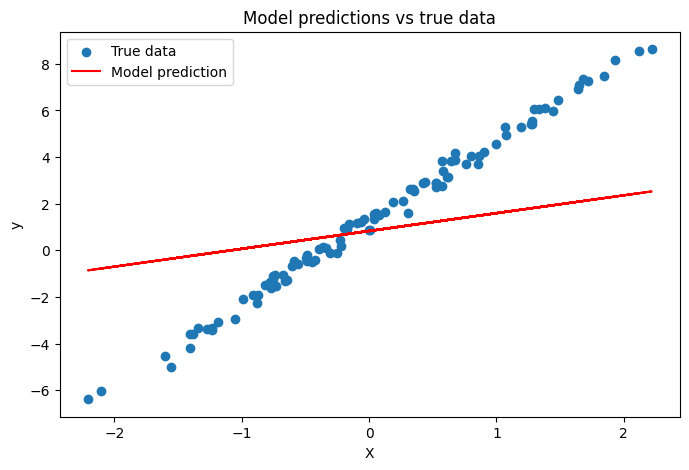

In [81]:
# 2.a.3
# make predictions
pred = model(X)
pred_np = pred.detach().numpy()
X_np = X.numpy()
y_np = y.numpy()

# plot predictions against true data
plt.figure(figsize=(8, 5))
plt.scatter(X_np, y_np, label='True data')
plt.plot(X_np, pred_np, color='red', label='Model prediction')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Model predictions vs true data')
plt.show()

**(2b)** Implement the training loop to fit the model. Use:

-   Loss function: `nn.MSELoss()`
-   Optimizer: `optim.SGD(model.parameters(), lr=0.1)`
-   Train for 100 epochs

The training loop should follow this pattern:

``` python
for epoch in range(n_epochs):
    # 1. Forward pass: compute predictions
    # 2. Compute loss
    # 3. Zero gradients: optimizer.zero_grad()
    # 4. Backward pass: loss.backward()
    # 5. Update parameters: optimizer.step()
```

Store the loss at each epoch and plot the loss curve.

In [82]:
# 2.b
torch.set_rng_state(rng_state) # to manage reproducibility

# Define loss function, optimizer and number of epochs
loss_func = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
n_epochs = 100

# training loop for 100 epochs
losses = []

for epoch in range(n_epochs):
    pred = model(X)  # 1. Forward pass
    loss = loss_func(pred, y)  # 2. Compute loss
    optimizer.zero_grad()  # 3. Zero gradients
    loss.backward()  # Backward pass
    optimizer.step()  # Update parameters

    losses.append(loss.item())

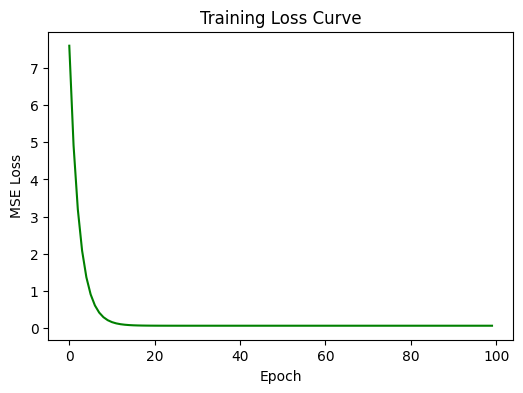

In [83]:
# plotting the loss curve
plt.figure(figsize=(6, 4))
plt.plot(losses, color='green')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve')
plt.show()

**(2c)** After training:

1.  Print the learned weight and bias

In [87]:
# 2.c.1
print(f'Learned Model Weight: \n {model.weight.item()}')
print(f'Learned Model Bias: \n {model.bias.item()}')

Learned Model Weight: 
 3.50354266166687
Learned Model Bias: 
 1.2107025384902954


2.  Compute the analytical OLS solution:
    $\hat{\beta} = (X^\top X)^{-1} X^\top y$ (hint: add a column of ones
    for the intercept)

In [88]:
# 2.c.2
intercept_column = torch.ones(X.size())
X2 = torch.cat([intercept_column, X], dim=1)
beta_hat = torch.inverse((X2.T) @ (X2)) @ X2.T @ y
print(f'Analytical OLS solution for intercept: \n {beta_hat[0, 0].item()}')
print(f'Analytical OLS solution for slope: \n {beta_hat[1, 0].item()}')

Analytical OLS solution for intercept: 
 1.2107023000717163
Analytical OLS solution for slope: 
 3.5035433769226074


3.  Compare the SGD estimates to both the OLS solution and the true
    values (3.5 and 1.2)

In [89]:
# 2.c.3
intercept_difference_SGD_true = model.bias.item() - 1.2
slope_difference_SGD_true = model.weight.item() - 3.5
intercept_difference_OLS_true = beta_hat[0, 0].item() - 1.2
slope_difference_OLS_true = beta_hat[1, 0].item() - 3.5
intercept_difference_SGD_OLS = model.bias.item() - beta_hat[0, 0].item()
slope_difference_SGD_OLS = model.weight.item() - beta_hat[1, 0].item()

print(f'Difference between SGD estimate for intercept and true value: {intercept_difference_SGD_true}')
print(f'Difference between SGD estimate for slope and true value: {slope_difference_SGD_true}')
print(f'Difference between OLS estimate for intercept and true value: {intercept_difference_OLS_true}')
print(f'Difference between OLS estimate for slope and true value: {slope_difference_OLS_true}')
print(f'Difference between SGD and OLS estimate for intercept: {intercept_difference_SGD_OLS}')
print(f'Difference between SGD and OLS estimate for slope: {slope_difference_SGD_OLS}')

Difference between SGD estimate for intercept and true value: 0.010702538490295455
Difference between SGD estimate for slope and true value: 0.003542661666870117
Difference between OLS estimate for intercept and true value: 0.010702300071716353
Difference between OLS estimate for slope and true value: 0.003543376922607422
Difference between SGD and OLS estimate for intercept: 2.384185791015625e-07
Difference between SGD and OLS estimate for slope: -7.152557373046875e-07


4.  Plot the learned regression line alongside the data

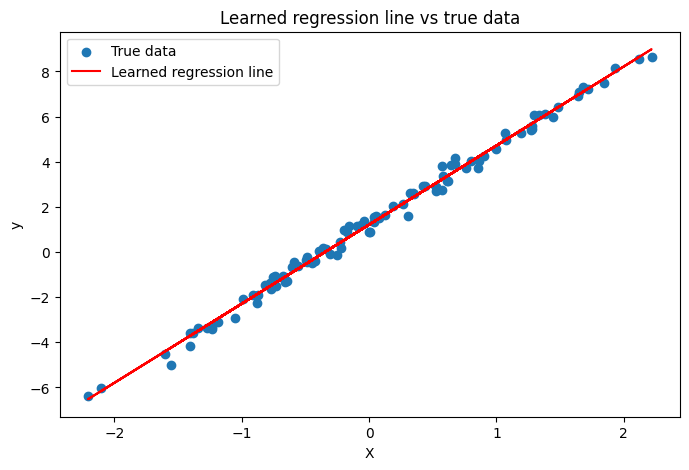

In [90]:
# 2.c.4
# extract learned regression line
pred_np = pred.detach().numpy()

# plot learned regression line against true data
plt.figure(figsize=(8, 5))
plt.scatter(X_np, y_np, label='True data')
plt.plot(X_np, pred_np, color='red', label='Learned regression line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Learned regression line vs true data')
plt.show()

**(2d)** Compare SGD with the Adam optimizer (`optim.Adam`). Retrain the
model with both optimizers and plot their loss curves. Which converges
faster?

In [91]:
# 2.d
torch.set_rng_state(rng_state) # to manage reproducibility
model = nn.Linear(in_features=1, out_features=1) # reset model weights

# Define loss function, optimizer and number of epochs
loss_func = nn.MSELoss()
optimizer2 = optim.Adam(model.parameters(), lr=0.1)
n_epochs = 100

# training loop for 100 epochs
losses_adam = []

for epoch in range(n_epochs):
    pred = model(X)  # 1. Forward pass
    loss = loss_func(pred, y)  # 2. Compute loss
    optimizer2.zero_grad()  # 3. Zero gradients
    loss.backward()  # Backward pass
    optimizer2.step()  # Update parameters

    losses_adam.append(loss.item())

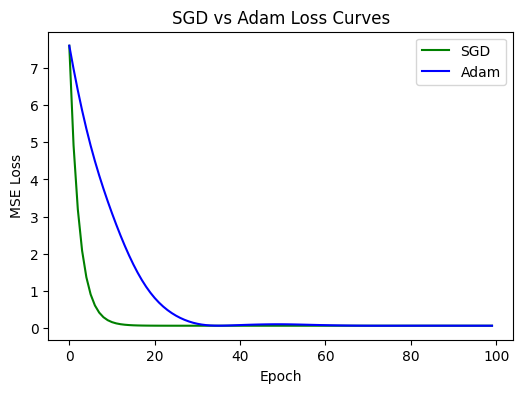

In [92]:
# loss comparison plot
plt.figure(figsize=(6, 4))
plt.plot(losses, color='green', label='SGD')
plt.plot(losses_adam, color='blue', label='Adam')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('SGD vs Adam Loss Curves')
plt.show()

SGD converges faster than Adam in this setting, likely because the true model is a linear regression with a relatively small sample (100 points). Adam may converge faster if the function was more complex e.g. higher dimensional.

# Problem 3: Multi-Layer Perceptron on MNIST

In this problem, you will build a multi-layer perceptron (MLP) to
classify handwritten digits from the MNIST dataset.

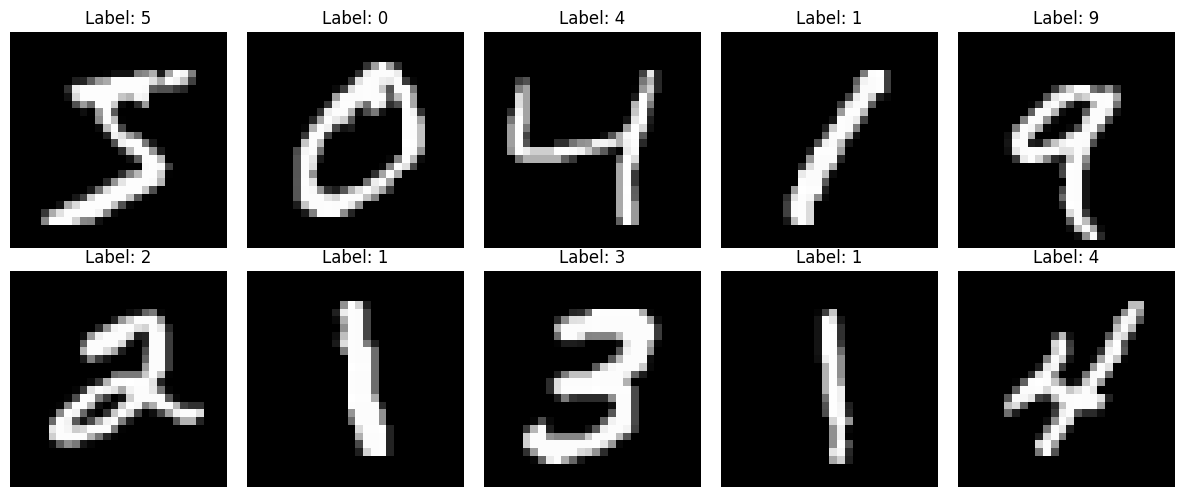

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


In [93]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Visualize some examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

**(3a)** Build an MLP with the following architecture using
`nn.Sequential`:

-   Input: 784 features (28×28 flattened image)
-   Hidden layer 1: 256 units, ReLU activation
-   Hidden layer 2: 128 units, ReLU activation
-   Output: 10 units (one per digit class)

Print the model architecture and count the total number of parameters.

In [94]:
# 3.a
torch.set_rng_state(rng_state) # to manage reproducibility

mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

print('Model architecture:')
print(mlp)

param_total = sum(p.numel() for p in mlp.parameters())
print(f'Total number of parameters: {param_total}')

Model architecture:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)
Total number of parameters: 235146


**(3b)** Train the model:

-   Loss function: `nn.CrossEntropyLoss()` (combines softmax and
    negative log-likelihood)
-   Optimizer: `optim.Adam(model.parameters(), lr=0.001)`
-   Train for 5 epochs

For each epoch, compute and print:

1.  Average training loss
2.  Training accuracy
3.  Test accuracy

Use this helper function to compute accuracy:

In [95]:
def compute_accuracy(model, data_loader):
    model.eval()  # Sets evaluation mode (disables dropout/batchnorm training behavior)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [96]:
# 3.b
torch.set_rng_state(rng_state) # to manage reproducibility

# Define loss function, optimizer and number of epochs
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)
n_epochs = 5

# training loop for 5 epochs
train_losses = []
train_accuracies = []
test_accuracies = []


for epoch in range(n_epochs):
    mlp.train()
    running_loss = 0.0


    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        pred = mlp(images)  # 1. Forward pass
        loss = loss_func(pred, labels)  # 2. Compute loss
        optimizer.zero_grad()  # 3. Zero gradients
        loss.backward()  # Backward pass
        optimizer.step()  # Update parameters

        running_loss += loss.item() * labels.size(0)
    
    # compute average loss and accuracies
    avg_train_loss = running_loss / len(train_loader.dataset)
    train_acc = compute_accuracy(mlp, train_loader)
    test_acc = compute_accuracy(mlp, test_loader)

    # store average loss and accuracies
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # print summary each epoch
    print(f'Epoch {epoch+1}/{n_epochs}, '
          f'Average Training Loss: {avg_train_loss}, '
          f'Training Accuracy: {train_acc}%, '
          f'Test Accuracy: {test_acc}%')

Epoch 1/5, Average Training Loss: 0.2331832667609056, Training Accuracy: 96.80666666666667%, Test Accuracy: 96.38%
Epoch 2/5, Average Training Loss: 0.09644237805704275, Training Accuracy: 98.18166666666667%, Test Accuracy: 97.27%
Epoch 3/5, Average Training Loss: 0.06542446101581056, Training Accuracy: 98.56%, Test Accuracy: 97.62%
Epoch 4/5, Average Training Loss: 0.05306326483587424, Training Accuracy: 98.68666666666667%, Test Accuracy: 97.42%
Epoch 5/5, Average Training Loss: 0.03911128424399843, Training Accuracy: 99.06833333333333%, Test Accuracy: 97.58%


**(3c)** Evaluate and visualize:

1.  Plot the training loss and accuracies over epochs
2.  Display 10 test images with their predicted labels. Mark incorrect
    predictions in red.
3.  What test accuracy did you achieve? How does this compare to random
    guessing (10%)?

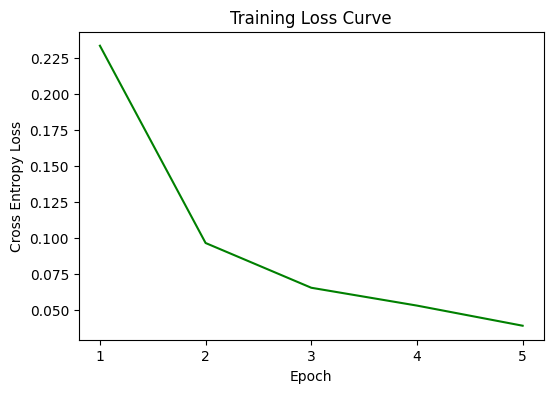

In [97]:
# 3.c.1
# training loss plot over epochs
# get human interpretable epoch range
plot_epochs = range(1, n_epochs + 1)

# plotting
plt.figure(figsize=(6, 4))
plt.plot(plot_epochs, train_losses, color='green')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.xticks(plot_epochs)
plt.title('Training Loss Curve')
plt.show()

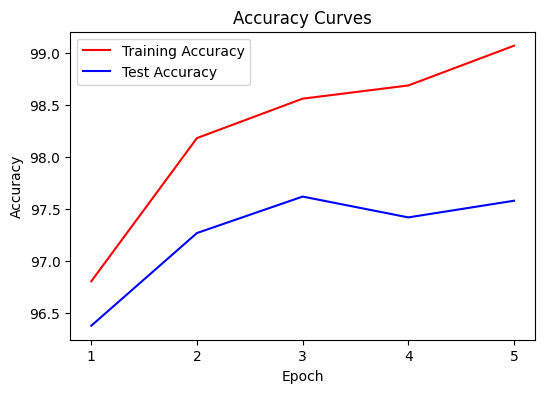

In [98]:
# accuracies plot over epochs
plt.figure(figsize=(6, 4))
plt.plot(plot_epochs, train_accuracies, color='red', label='Training Accuracy')
plt.plot(plot_epochs, test_accuracies, color='blue', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(plot_epochs)
plt.legend()
plt.title('Accuracy Curves')
plt.show()

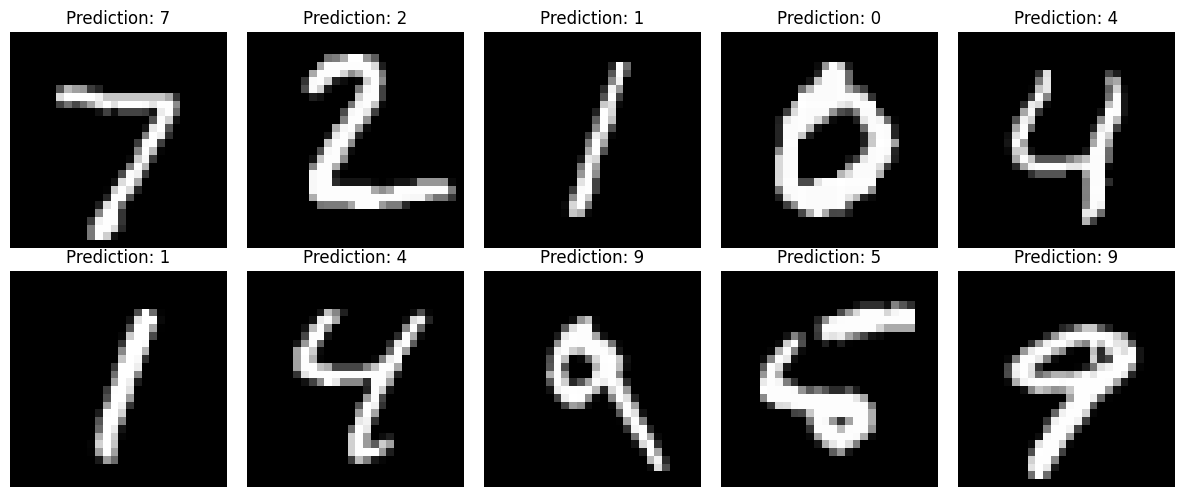

In [99]:
# 10 test images with their predicted labels
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, true_label = test_dataset[i]
    input_img = img.unsqueeze(0).to(device)

    output = mlp(input_img)
    _, pred_label = torch.max(output, 1)
    pred_label = pred_label.item()

    color = 'red' if pred_label != true_label else 'black'

    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Prediction: {pred_label}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [100]:
# 3.c.3
print(f'Test Accuracy Achieved: {test_accuracies[-1]}%')
print(f'Comparison to random guessing: {test_accuracies[-1] - 10}% points better')

Test Accuracy Achieved: 97.58%
Comparison to random guessing: 87.58% points better


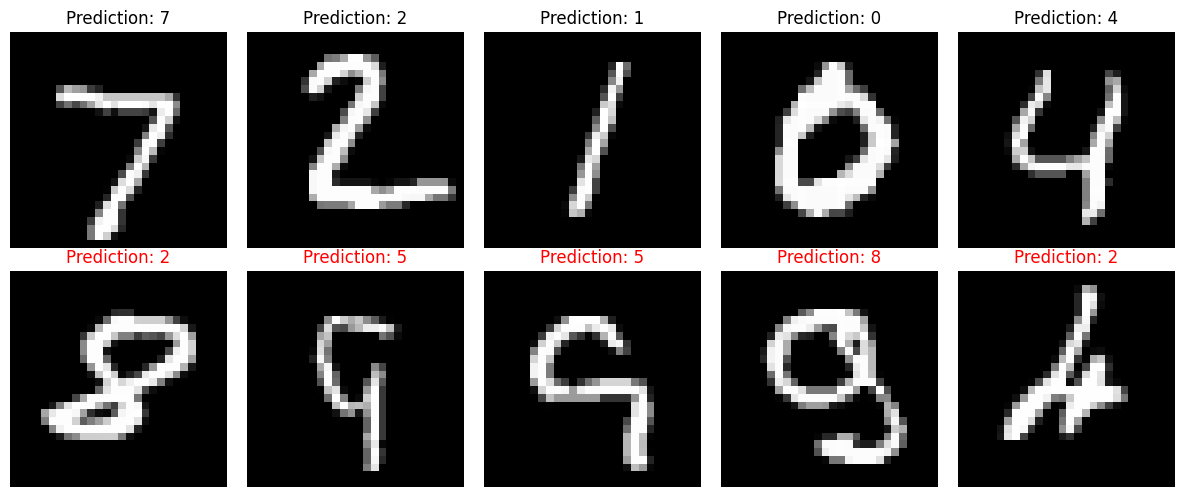

In [65]:
# Extra code to draw some incorrect examples to test the plotting
import torch
import matplotlib.pyplot as plt

mlp.eval()  # Set model to evaluation mode

correct = []
incorrect = []

for img, label in test_dataset:
    input_img = img.unsqueeze(0).to(device)
    output = mlp(input_img)
    _, pred_label = torch.max(output, 1)
    pred_label = pred_label.item()

    if pred_label == label:
        correct.append((img, label, pred_label))
    else:
        incorrect.append((img, label, pred_label))

    if len(correct) >= 5 and len(incorrect) >= 5:
        break

# pick the first 10 images from the test dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
examples = correct[:5] + incorrect[:5]
for i, ax in enumerate(axes.flat):
    img, true_label, pred_label = examples[i]
    color = 'red' if pred_label != true_label else 'black'

    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Prediction: {pred_label}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()
